In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.backend import clear_session
from tensorflow.keras.layers import InputLayer,Dense, Conv2D, MaxPool2D, \
BatchNormalization, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import array_to_img

# Descrizione approccio

Il dataset suggerito dalla richiesta del progetto è stato modificato secondo il seguente approccio: vista l'applicazione richiesta, si è pensato di creare un modello per applicazione veicolare terrestre. Sì è pertanto proceduto all'eliminazione dal dataset delle immagini e delle classi relative a imbarcazioni ed velivoli aerei. Si è poi proceduto alla creazione di una CNN con loss di tipo binary_crossentropy, in quanto le classi sono state ridotte a 2.

NB: il codice è stato predisposto per permettere il salvataggio dei pesi e dello storico delle epoche di addestramento per ciascuna rete, così come la possibilità di caricare da link condiviso GDrive; quest'ultima possibilità risulta commentata appositamente, per permettere in prima istanza l'esecuzione del training.

# Donwload del dataset

In [ ]:
cifar10 = tf.keras.datasets.cifar10

# Data preprocessing

In [ ]:
clear_session()

In [ ]:
# 0 → airplane (da eliminare)
# 1 → automobile
# 2 → bird
# 3 → cat
# 4 → deer
# 5 → dog
# 6 → frog
# 7 → horse
# 8 → ship (da eliminare)
# 9 → truck

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.flatten() # flattening per poter processare meglio il vettore
y_test = y_test.flatten() # flattening per poter processare meglio il vettore

# classi da tenere
vehicle_classes = [1, 9]      # veicoli --> automobile, truck
animal_classes  = [2,3,4,5,6,7] # bird, cat, deer, dog, frog, horse

keep_classes = vehicle_classes + animal_classes # somma delle classi da tenere

train_mask = np.isin(y_train, keep_classes) # maschera per tenere solo le classi utili alla nostra classificazione
test_mask  = np.isin(y_test, keep_classes) # maschera per tenere solo le classi utili alla nostra classificazione

x_train, y_train = x_train[train_mask], y_train[train_mask] # dataset pulito
x_test, y_test   = x_test[test_mask], y_test[test_mask] # dataset pulito

x_train, x_test = x_train/255, x_test/255

x_train_plt = x_train.copy()
y_train_plt = y_train.copy()
x_test_plt = x_test.copy()
y_test_plt = y_test.copy()

# classi binarie: 1 = veicolo; 0 = animale
y_train_binary = np.isin(y_train, vehicle_classes).astype(int)
y_test_binary  = np.isin(y_test, vehicle_classes).astype(int)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 138s 1us/step


In [ ]:
# --- analisi sbilanciamenti:
np.unique(y_train_binary, return_counts=True) # (array([0, 1]), array([30000, 10000])) --> dataset sbilanciato 3:1


(array([0, 1]), array([30000, 10000]))

In [ ]:
# --- downsizing del dataset:

idx_0 = np.where(y_train_binary == 0)[0]  # animal --> indicizzo immagini animal
idx_1 = np.where(y_train_binary == 1)[0]  # vehicle --> indicizzo immagini vehicle

np.random.seed(42)
idx_0_down = np.random.choice(idx_0, size=len(idx_1), replace=False) # riduco dimensione vettore indici di animal (da 3000 a 1000)

idx_final = np.concatenate([idx_0_down, idx_1]) # concateno i vettori degli indici
np.random.shuffle(idx_final) # mischietta

X_train_bal = x_train[idx_final]
y_train_bal = y_train_binary[idx_final]

In [ ]:
# --- analisi sbilanciamenti:
np.unique(y_train_bal, return_counts=True) # (array([0, 1]), array([10000, 10000])) --> dataset bilanciato

(array([0, 1]), array([10000, 10000]))

# Data augmentation

Per compensare (parzialmente) la perdita di dati dovuta al downsizing che si è reso necessario per rispettare l'approccio, si è proceduto ad usare la tecnica del data augmentation per raggiungere risultati di addestramenti migliori.

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_bal)

# Example visualization

Text(0.5, 1.0, 'truck')

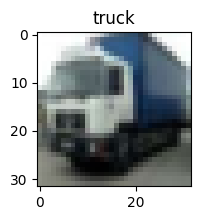

In [ ]:
labels = ['airplane' ,'automobile'  ,'bird' , 'cat' ,  'deer',   'dog','frog','horse' ,'ship' ,'truck']
plt.figure(figsize=(2,2))
indx = np.random.choice(range(50000))
plt.imshow(x_train_plt[indx])
plt.title(labels[y_train_plt[indx]])

# Creazione rete contenente CNN

E' stata creata una rete contenente un solo strato convoluzionale per esplorare la capacità del modello di far fronte a tempi ridotti di training. Risultato discreto (vedasi accuracy)

In [ ]:
w_init = tf.keras.initializers.RandomNormal(stddev=0.01)
cnn1 = Sequential([
    InputLayer(input_shape=(32,32,3)),
    Conv2D(filters=96, kernel_size=(3,3), strides=(1,1),
           kernel_initializer=w_init, bias_initializer='zeros',activation='relu'),
    MaxPool2D(pool_size=(3,3), strides=(2,2)),
    Flatten(),
    Dense(1, kernel_initializer=w_init, bias_initializer='zeros', activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
cnn1.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics = ['accuracy']
            )

In [ ]:
cnn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        18,817 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,505 (84.00 KB)

 Trainable params: 21,505 (84.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Training modello

hist1 = cnn1.fit(
    datagen.flow(X_train_bal, y_train_bal, batch_size=64),
    epochs=10,
    validation_data=(x_test, y_test_binary)
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 144ms/step - accuracy: 0.8084 - loss: 0.4217 - val_accuracy: 0.7832 - val_loss: 0.4789
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.8834 - loss: 0.2924 - val_accuracy: 0.8391 - val_loss: 0.3948
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.8935 - loss: 0.2666 - val_accuracy: 0.9079 - val_loss: 0.2371
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.8967 - loss: 0.2543 - val_accuracy: 0.8518 - val_loss: 0.3754
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.9018 - loss: 0.2468 - val_accuracy: 0.9050 - val_loss: 0.2448
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.9024 - loss: 0.2468 - val_accuracy: 0.9277 - val_loss: 0.1969
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.9054 - loss: 0.2366 - val_accuracy: 0.8551 - val_loss: 0.3617
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 143ms/step - accuracy: 0.9062 - loss: 0

In [ ]:
# --- salvataggio e caricamento hist

import json

with open("hist_cnn1.json", "w") as f:
    json.dump(hist1.history, f)

# file_id = "1i2q8nWi5GUyziODlDiByVY1XFYf0BuJ6"
# url = f"https://drive.google.com/uc?id={file_id}"

# gdown.download(url, "hist_cnn1.json", quiet=False)

# with open("hist_cnn1.json", "r") as f:
#     history = json.load(f)

In [ ]:
# --- salvataggio pesi

cnn1.save_weights("weights_cnn1.weights.h5") # --> commentato in quanto già salvati in passato

In [ ]:
# --- scarico nella folder di questo notebook i pesi cnn1 e li carico

import gdown

file_id = "1cpE4kNvSEdTKu7W3kuXPMnzsVzZKN_Hj"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "weights_cnn1.weights.h5", quiet=False)

cnn1.load_weights("weights_cnn1.weights.h5")

Downloading...
From: https://drive.google.com/uc?id=1cpE4kNvSEdTKu7W3kuXPMnzsVzZKN_Hj
To: /content/weights_cnn1.weights.h5
100%|██████████| 281k/281k [00:00<00:00, 59.3MB/s]


In [ ]:
predictions_cnn1 = cnn1.predict(x_test)
str_preds_cnn1 = np.where(predictions_cnn1.flatten() > 0.5, 'vehicle', 'animal')
cnames = ['animal','vehicle']

250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


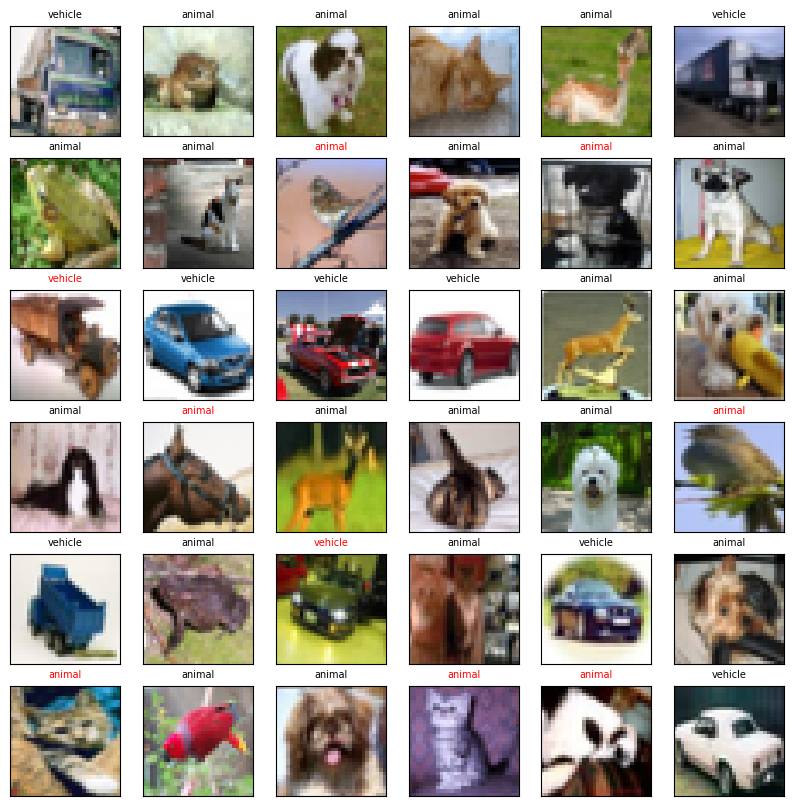

In [ ]:
plt.figure(figsize=(10,10))
idx = np.random.randint(0, len(x_test_plt), 36)
for k in range(36):
    plt.subplot(6,6,k+1)
    plt.imshow(array_to_img(x_test_plt[idx[k]]))
    plt.xticks([],[])
    plt.yticks([],[])
    ml_pred = str_preds_cnn1[idx[k]]
    gt_label = cnames[y_test_binary[idx[k]]]
    plt.title(gt_label, fontsize=7,\
             color='black' if ml_pred == gt_label else 'red')
plt.tight_layout;

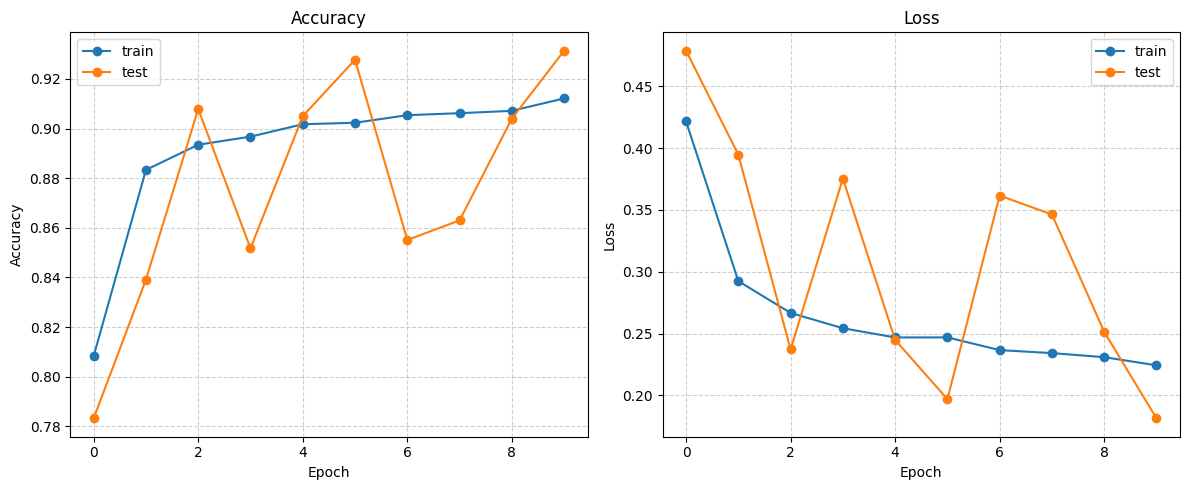

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- ACCURACY ---
axes[0].plot(hist1.history['accuracy'], marker='o', label='train')
axes[0].plot(hist1.history['val_accuracy'], marker='o', label='test')
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- LOSS ---
axes[1].plot(hist1.history['loss'], marker='o', label='train')
axes[1].plot(hist1.history['val_loss'], marker='o', label='test')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- confusion matrix

from sklearn.metrics import confusion_matrix

p = (cnn1.predict(x_test).flatten() > 0.5).astype(int)

cm = confusion_matrix(y_test_binary, p)
print(cm)

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
[[5006  994]
 [  45 1955]]


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


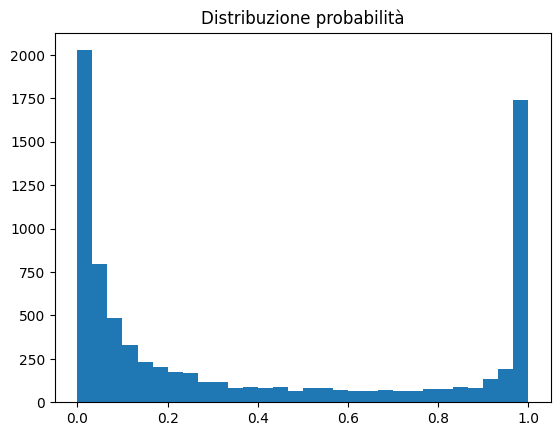

In [ ]:
probs = cnn1.predict(x_test).flatten()
# --- distribuzione sbilanciata verso la classe "animal"
plt.hist(probs, bins=30)
plt.title("Distribuzione probabilità")
plt.show()

# Miglioramento CNN aggiungendo più strati convoluzionali per estraree maggiori dettagli di pattern

L’utilizzo di più layer convoluzionali consente alla rete di apprendere rappresentazioni gerarchiche delle immagini. I primi layer estraggono feature di basso livello (bordi, texture), mentre i layer più profondi catturano pattern più complessi (forme di animali o strutture dei veicoli).
Questo è particolarmente importante nel dataset CIFAR-10, dove le immagini hanno bassa risoluzione e richiedono una maggiore profondità del modello per distinguere correttamente le classi.

La Batch Normalization è stata introdotta per stabilizzare e accelerare il processo di addestramento. Normalizzando le attivazioni intermedie, il modello diventa meno sensibile all’inizializzazione dei pesi e consente l’utilizzo di learning rate più elevati

In [ ]:
cnn2 = Sequential([

    InputLayer(input_shape=(32,32,3)),

    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
cnn2.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics = ['accuracy']
            )

In [ ]:
# --- Training modello: commentato perché lungo. Sono stati quindi salvati i pesi in modo da poter essere caricati skippando il tempo di training.

hist2 = cnn2.fit(
    datagen.flow(X_train_bal, y_train_bal, batch_size=64),
    epochs=10,
    validation_data=(x_test, y_test_binary)
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 168s 517ms/step - accuracy: 0.8582 - loss: 0.3709 - val_accuracy: 0.7504 - val_loss: 2.7987
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 510ms/step - accuracy: 0.9086 - loss: 0.2385 - val_accuracy: 0.9421 - val_loss: 0.1742
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 157s 502ms/step - accuracy: 0.9232 - loss: 0.2027 - val_accuracy: 0.9526 - val_loss: 0.1250
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 157s 502ms/step - accuracy: 0.9329 - loss: 0.1786 - val_accuracy: 0.9521 - val_loss: 0.1211
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 216s 548ms/step - accuracy: 0.9427 - loss: 0.1528 - val_accuracy: 0.7876 - val_loss: 0.7250
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 507ms/step - accuracy: 0.9459 - loss: 0.1426 - val_accuracy: 0.8881 - val_loss: 0.3234
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 510ms/step - accuracy: 0.9517 - loss: 0.1315 - val_accuracy: 0.6534 - val_loss: 1.3016
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 166s 530ms/step - accuracy: 0.9546 -

In [ ]:
# --- salvataggio e caricamento hist

import json

with open("hist_cnn2.json", "w") as f:
    json.dump(hist2.history, f)

# import gdown

# file_id = "1tEzpPWqUU8BPDDVXPOSuNsyU-te_WhrX"
# url = f"https://drive.google.com/uc?id={file_id}"

# gdown.download(url, "hist_cnn1.json", quiet=False)

# with open("hist_cnn2.json", "r") as f:
#     history = json.load(f)

In [ ]:
# --- salvataggio pesi

cnn2.save_weights("weights_cnn2.weights.h5") # --> commentato in quanto già salvati in passato

In [ ]:
# --- scarico nella folder di questo notebook i pesi cnn2 e li carico

# import gdown

# file_id = "190TMOM_k8xJUAGlisMRnp2oa0rLNsatz"
# url = f"https://drive.google.com/uc?id={file_id}"

# gdown.download(url, "weights_cnn2.weights.h5", quiet=False)

# cnn2.load_weights("weights_cnn2.weights.h5")

In [ ]:
# --- effetto del threeshold per provare a ridurre lo sbilanciamento delle predizioni.

from sklearn.metrics import precision_score, recall_score

probs = cnn2.predict(x_test).flatten()

for th in [0.3, 0.5, 0.7, 0.9]:
    p = (probs > th).astype(int)
    prec = precision_score(y_test_binary, p)
    rec  = recall_score(y_test_binary, p)
    print(f"th={th} → precision={prec:.3f}, recall={rec:.3f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step
th=0.3 → precision=0.902, recall=0.972
th=0.5 → precision=0.938, recall=0.953
th=0.7 → precision=0.966, recall=0.932
th=0.9 → precision=0.986, recall=0.885


In [ ]:
predictions_cnn2 = cnn2.predict(x_test)
str_preds_cnn2 = np.where(predictions_cnn2.flatten() > 0.5, 'vehicle', 'animal')
cnames = ['animal','vehicle']

250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step


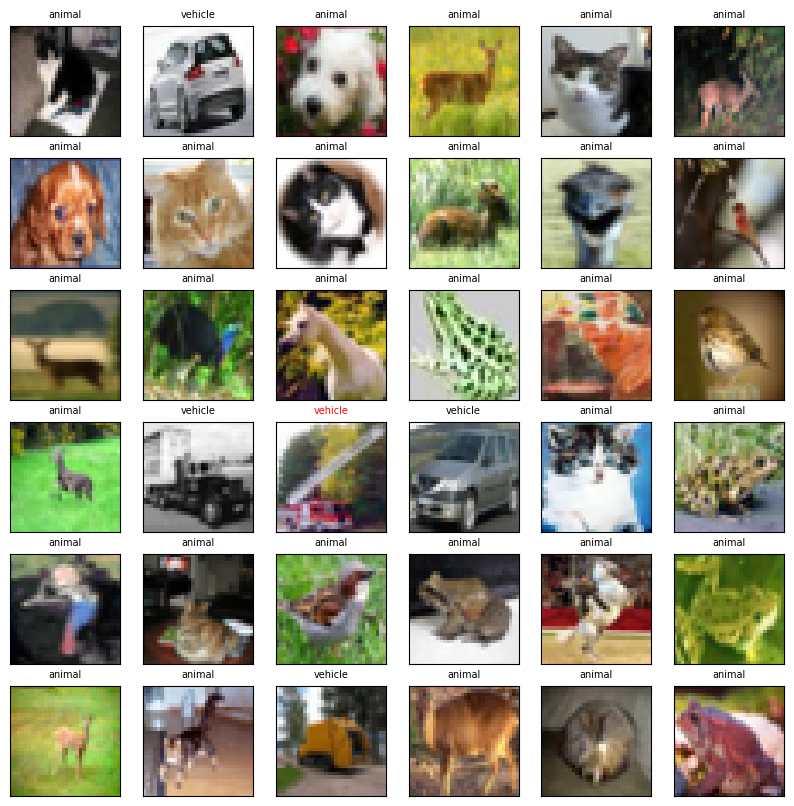

In [ ]:
plt.figure(figsize=(10,10))
idx = np.random.randint(0, len(x_test_plt), 36)
for k in range(36):
    plt.subplot(6,6,k+1)
    plt.imshow(array_to_img(x_test_plt[idx[k]]))
    plt.xticks([],[])
    plt.yticks([],[])
    ml_pred = str_preds_cnn2[idx[k]]
    gt_label = cnames[y_test_binary[idx[k]]]
    plt.title(gt_label, fontsize=7,\
             color='black' if ml_pred == gt_label else 'red')
plt.tight_layout;

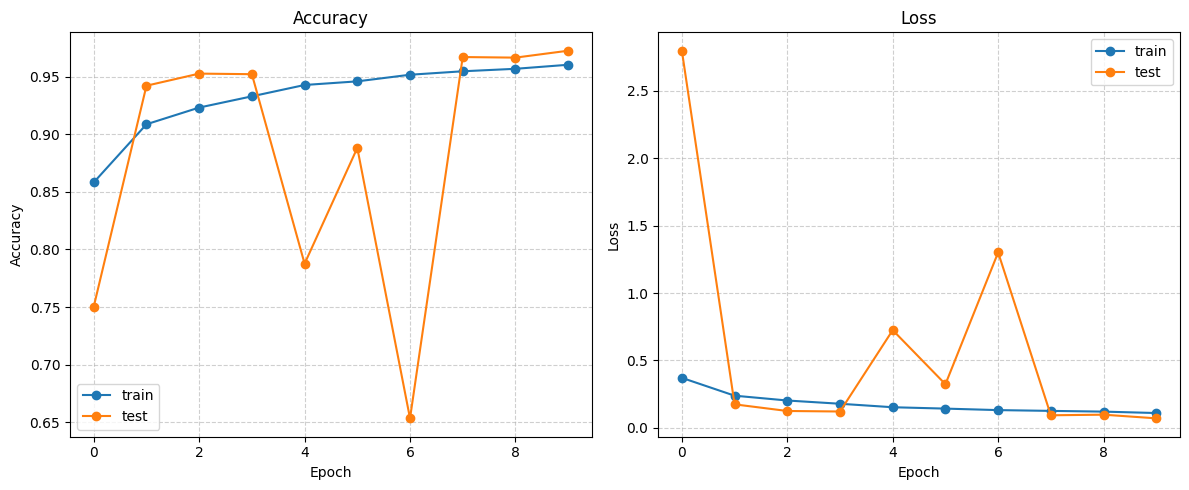

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- ACCURACY ---
axes[0].plot(hist2.history['accuracy'], marker='o', label='train')
axes[0].plot(hist2.history['val_accuracy'], marker='o', label='test')
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- LOSS ---
axes[1].plot(hist2.history['loss'], marker='o', label='train')
axes[1].plot(hist2.history['val_loss'], marker='o', label='test')
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- confusion matrix

from sklearn.metrics import confusion_matrix

p = (cnn2.predict(x_test).flatten() > 0.5).astype(int)

cm = confusion_matrix(y_test_binary, p)
print(cm)

250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step
[[5875  125]
 [  95 1905]]


250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step


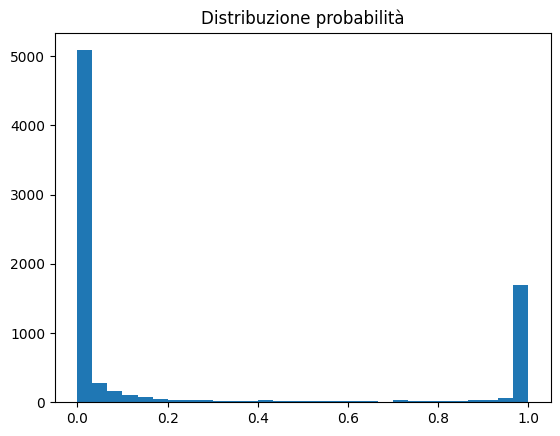

In [ ]:
probs = cnn2.predict(x_test).flatten()
# --- distribuzione sbilanciata verso la classe "animal" ma più definita di sicurezza.
plt.hist(probs, bins=30)
plt.title("Distribuzione probabilità")
plt.show()

# Conclusioni
i 2 modelli adoperati mostrano risultati accettabili in termini di accuracy e precision. Più precisamente:
cnn1 risulta più aggressivo nei confronti di selezione classificazione vehicle (vedi confusion matrix) ma più rapido nel training (12 min)
cnn2 risulta più bilanciato e preciso (confusion matrix più bilanciata) ma più lento (44 min).

l'aggressività può essere esplorata e migliorata a seconda delle esigenze (es: salvare gli animali) mediante un trade-off "guidabilità" vs "salvare animali" modificando il threeshold th (come già esplorato mediante sweep on ciclo for)

la distribuzione delle probabilità risulta più definita con cnn2 (vedasi grafici sopra), segno di sicurezza del modello, ritenuto quindi accettabile per eventuale deployment.

le oscillazioni dei grafici "accuracy e loss vs epoch"  sui dati di validation sono probabilmente dovute alla differenza tra dati augmentati in training e dati reali in validazione, che introduce variabilità nelle performance tra epoche. Anche la riduzione del dataset ha sicuramente causato l'effetto.

# Limiti
- dataset CIFAR ha risoluzione limitata --> modello limitato nelle sue capacità
- necessità di testare il modello con immagini con risoluzione migliore in modo da testarne il rumore --> affidabilità modello per contesto "reale" limitata